# YouTube Video Data - Exploratory Data Analysis (EDA)

This notebook presents a comprehensive exploratory data analysis of a YouTube video dataset. The analysis proceeds through data quality assessment, univariate and bivariate examination of key variables, derivation of engagement metrics, and investigation of relationships between technical, textual, and engagement-related features. The findings inform methodological choices for subsequent predictive modelling and provide an empirical basis for understanding content-level determinants of audience engagement on the platform.

---
## 1. Environment Setup & Data Loading

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 60)

# Plot style - modern and readable
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except (OSError, ValueError):
    try:
        plt.style.use('seaborn-whitegrid')
    except (OSError, ValueError):
        pass
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Load data
df = pd.read_csv('youtube_data.csv')
df_raw = df.copy()

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
df.head(10)

Dataset shape: 17,589 rows × 17 columns
Memory usage: 12.84 MB


,video_id,duration,bitrate,bitrate(video),height,width,frame rate,frame rate(est.),codec,category,url,title,description,hashtags,views,likes,comments
0,--F7dc-_FSI,180,5777,5640,1920,1080,25.00,25.00,h264,News & Politics,https://www.youtube.com/watch?v=--F7dc-_FSI,«السودان ينتفض» أمام السفارة بالقاهرة,حرية سلام وعدالة، الثورة خيار الشعب.. بهذا الهتاف تجمع ع...,"في, عسكري, حكم, حرية, بخصوص, المصري اليوم, السودان, قوات...",4078,41,3
1,--cCAD-8Y_U,930,1195,1001,1280,720,30.00,30.00,h264,Gaming,https://www.youtube.com/watch?v=--cCAD-8Y_U,Pokemon Tower Defense Episodio 2,Espero que tenham gostado do video!,"Pokémon (Anime/Manga Franchise), Pokémon (Video Game Ser...",33,2,1
2,--g2gG8pQ0w,233,3028,2833,1280,720,23.98,23.98,h264,Comedy,https://www.youtube.com/watch?v=--g2gG8pQ0w,New Hip Hop - Kemo Treats - Pancakes,Download all our music for FREE just enter $0. http://ke...,"breaking bad spoof, Recipes, Pancakes, canada, Cook, fun...",13227,135,17
3,-0DR7-voRCU,562,431,300,320,240,29.97,0.00,h264,People & Blogs,https://www.youtube.com/watch?v=-0DR7-voRCU,Sister's Keeper Impression,A Review of the Shampoo Bar(Sunburst) and Dip Moisturizer,"natural hair, first impression, sister's keeper products...",43,1,0
4,-0Fkp-2EzX0,300,3087,2929,1280,720,23.98,23.98,h264,Gaming,https://www.youtube.com/watch?v=-0Fkp-2EzX0,JBHAMMER777 (AKUMA) VS KtossPol Rank 1 (Vega) VS ma Chi...,JBHAMMER777 is he strong enough to fight against Tokido ...,"Tokido, momochi, (Ryu), AE, 11, at, Piyoppia, Street, Ki...",222,2,0
5,-0J-a-kKR1M,135,467,371,320,240,30.00,0.00,h264,People & Blogs,https://www.youtube.com/watch?v=-0J-a-kKR1M,D'Salapa mirae,,"mirae, D'Salapa",168,1,1
6,-0bc_-HP6dE,43,634,501,480,360,29.97,29.97,h264,Entertainment,https://www.youtube.com/watch?v=-0bc_-HP6dE,VATOz N DA BARRIO,PREVIEW,NASTY!!!,138,0,0
7,-0hjSaYCRnA,4,738,605,540,360,29.97,0.00,h264,Comedy,https://www.youtube.com/watch?v=-0hjSaYCRnA,Shiiiiiiiiiiiit,Shiiiiiiiiiiiiiiiiiit,"shiiiiiiiiiiiiiiit, the, wire",373587,1204,54
8,-0kAY-vAVBc,228,5880,5686,1920,1080,25.00,25.00,h264,Music,https://www.youtube.com/watch?v=-0kAY-vAVBc,LAURA POTHIN . DANS MES VEINES BY SUNSHINE974PROD,"Extrait du maxi CD ""Dans mes veines"" de Laura Pothin , d...","2013, La reunion, zouk love",1876,0,0
9,-0lNh-4ZuTE,268,492,364,640,360,25.00,0.00,h264,Education,https://www.youtube.com/watch?v=-0lNh-4ZuTE,Boonaa Mohammed - Killing with Love,Boonaa Mohammed - Killing with Love,NaN,50,1,0


---
## 2. Data Quality & Profiling

### 2.1 Basic Schema & Data Types

In [93]:
# Column info with details
def get_sample(col):
    try:
        if df[col].notna().any():
            return str(df[col].dropna().iloc[0])[:40]
    except (IndexError, KeyError):
        pass
    return 'N/A'

schema = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null': df.count().values,
    'Unique': [df[col].nunique() for col in df.columns],
    'Sample': [get_sample(col) for col in df.columns]
})
schema

,Column,Dtype,Non-Null,Unique,Sample
0,video_id,object,17589,17589,--F7dc-_FSI
1,duration,int64,17589,1320,180
2,bitrate,int64,17589,3512,5777
3,bitrate(video),int64,17589,3444,5640
4,height,int64,17589,266,1920
5,width,int64,17589,172,1080
6,frame rate,float64,17589,467,25.0
7,frame rate(est.),float64,17589,259,25.0
8,codec,object,17589,4,h264
9,category,object,17589,16,News & Politics


### 2.2 Missing Values Analysis

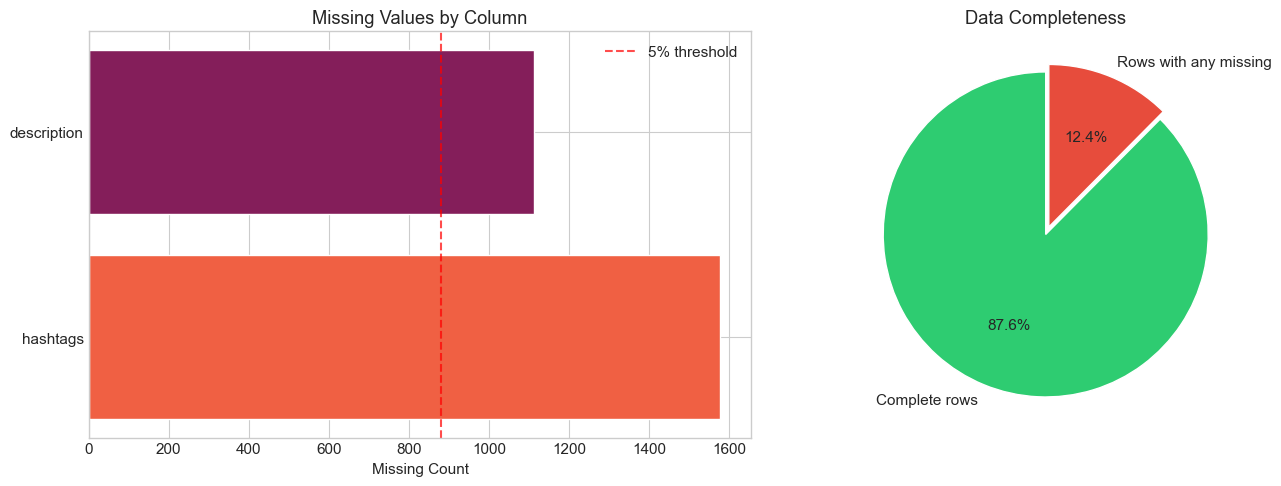

,Missing,Pct (%)
hashtags,1576,8.96
description,1112,6.32


In [94]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of missing values
if len(missing_df) > 0:
    bars = axes[0].barh(missing_df.index, missing_df['Missing'], color=sns.color_palette('rocket_r', len(missing_df)))
    axes[0].set_xlabel('Missing Count')
    axes[0].set_title('Missing Values by Column')
    axes[0].axvline(x=len(df)*0.05, color='red', linestyle='--', alpha=0.7, label='5% threshold')
    axes[0].legend()
    
    # Pie: complete vs incomplete rows
    complete = df.dropna().shape[0]
    incomplete = len(df) - complete
    axes[1].pie([complete, incomplete], labels=['Complete rows', 'Rows with any missing'], autopct='%1.1f%%', 
                colors=['#2ecc71', '#e74c3c'], explode=(0, 0.05), startangle=90)
    axes[1].set_title('Data Completeness')
else:
    axes[0].text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=14)
    axes[1].text(0.5, 0.5, '100% Complete', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

if len(missing_df) > 0:
    display(missing_df)

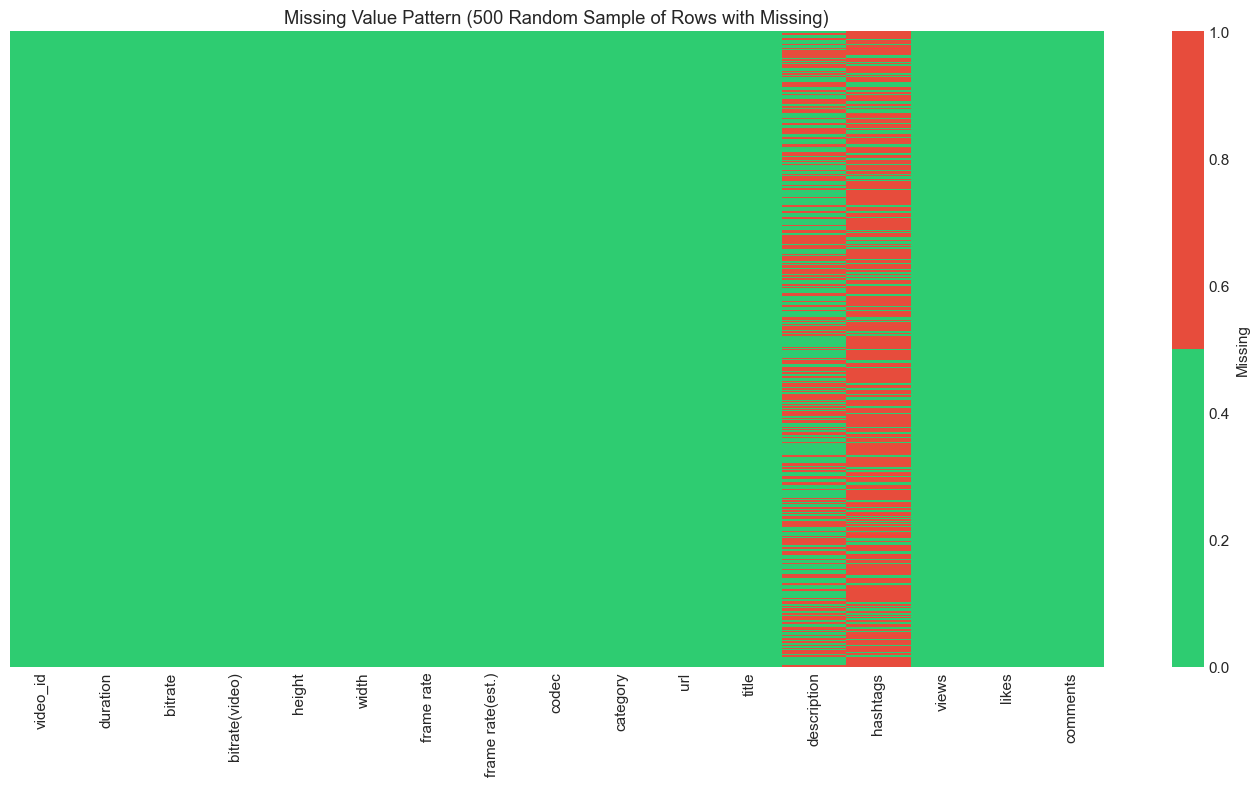

In [95]:
# Missing value heatmap (sample of rows with missing)
from matplotlib.colors import ListedColormap
miss_cmap = ListedColormap(['#2ecc71', '#e74c3c'])
rows_with_missing = df[df.isnull().any(axis=1)]
if len(rows_with_missing) > 0 and len(rows_with_missing) <= 500:
    plt.figure(figsize=(14, min(8, len(rows_with_missing) * 0.02)))
    sns.heatmap(rows_with_missing.isnull(), cbar_kws={'label': 'Missing'}, cmap=miss_cmap, yticklabels=False)
    plt.title('Missing Value Pattern (Rows with Any Missing)')
    plt.tight_layout()
    plt.show()
elif len(rows_with_missing) > 500:
    sample = rows_with_missing.sample(500, random_state=42)
    plt.figure(figsize=(14, 8))
    sns.heatmap(sample.isnull(), cbar_kws={'label': 'Missing'}, cmap=miss_cmap, yticklabels=False)
    plt.title('Missing Value Pattern (500 Random Sample of Rows with Missing)')
    plt.tight_layout()
    plt.show()

### 2.3 Duplicates & Data Integrity

In [96]:
# Duplicate check
dup_video_id = df['video_id'].duplicated().sum()
dup_rows = df.duplicated().sum()

print(f"Duplicate video_id: {dup_video_id}")
print(f"Fully duplicate rows: {dup_rows}")

if dup_video_id > 0:
    dup_ids = df[df['video_id'].duplicated(keep=False)]['video_id'].value_counts().head(5)
    print(f"\nSample duplicate video_ids:\n{dup_ids}")

Duplicate video_id: 0
Fully duplicate rows: 0


**Analysis.** The data quality assessment reveals the integrity of the sample for downstream modeling. The presence and distribution of missing values inform the choice of imputation strategies or exclusion criteria; columns exceeding a 5% missing threshold warrant careful consideration. Duplicate *video_id* entries, if present, may indicate data collection artifacts and should be reconciled prior to inferential analysis. The completeness profile establishes the analytical scope and supports transparency in reporting methodological limitations.

---
## 3. Descriptive Statistics

**Analysis.** The extended descriptive statistics provide essential context for variable scaling and model specification. Skewness and kurtosis indicate pronounced right-tailed distributions in engagement metrics (views, likes, comments), justifying log transformations for linear models. The interquartile range and full range reveal scale heterogeneity across variables; standardisation may be required for algorithms sensitive to feature magnitude. These statistics guide preprocessing decisions and inform expectations for residual diagnostics.

In [97]:
numeric_cols = ['duration', 'bitrate', 'bitrate(video)', 'height', 'width', 'frame rate', 'frame rate(est.)', 'views', 'likes', 'comments']
numeric_cols = [c for c in numeric_cols if c in df.columns]

# Extended statistics
stats = df[numeric_cols].describe().T
stats['skewness'] = df[numeric_cols].skew()
stats['kurtosis'] = df[numeric_cols].kurtosis()
stats['IQR'] = stats['75%'] - stats['25%']
stats['range'] = stats['max'] - stats['min']
stats.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,IQR,range
duration,17589.0,241.55,493.03,1.00,51.0,135.00,268.00,2.584500e+04,16.96,601.82,217.00,2.584400e+04
bitrate,17589.0,1271.35,1375.36,0.00,437.0,743.00,1293.00,2.242100e+04,2.41,8.76,856.00,2.242100e+04
bitrate(video),17589.0,1150.42,1351.80,0.00,326.0,632.00,1184.00,2.222900e+04,2.45,9.16,858.00,2.222900e+04
height,17589.0,766.78,467.29,108.00,426.0,640.00,960.00,2.592000e+03,1.12,0.47,534.00,2.484000e+03
width,17589.0,504.59,262.73,88.00,320.0,480.00,720.00,1.944000e+03,1.30,2.31,400.00,1.856000e+03
frame rate,17589.0,26.47,6.04,3.75,25.0,29.97,29.97,5.908000e+01,-1.36,2.87,4.97,5.533000e+01
frame rate(est.),17589.0,9.47,13.25,0.00,0.0,0.00,25.00,3.000000e+01,0.75,-1.36,25.00,3.000000e+01
views,17589.0,68941.58,3537491.15,0.00,38.0,152.00,800.00,4.103849e+08,97.62,10655.63,762.00,4.103849e+08
likes,17589.0,208.86,8477.50,0.00,0.0,1.00,4.00,8.369810e+05,75.60,6440.81,4.00,8.369810e+05
comments,17589.0,12.90,225.84,0.00,0.0,0.00,1.00,1.663400e+04,49.28,3119.74,1.00,1.663400e+04


---
## 4. Categorical Variables - Deep Dive

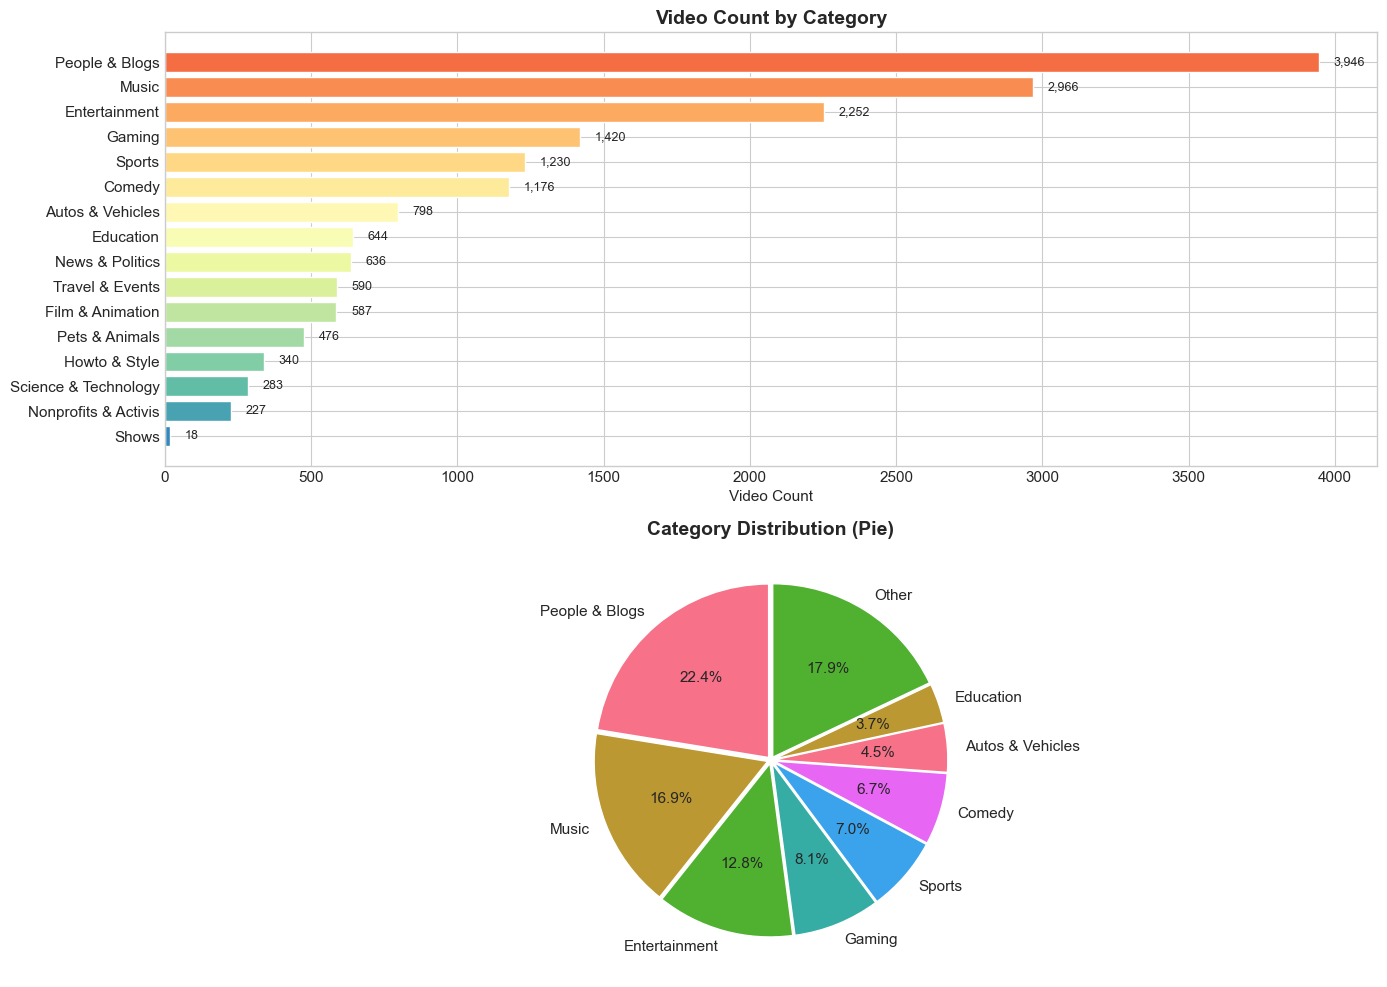

In [98]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Category - horizontal bar with value labels
cat_counts = df['category'].value_counts()
colors = plt.cm.Spectral(np.linspace(0.2, 0.9, len(cat_counts)))
bars = axes[0].barh(cat_counts.index, cat_counts.values, color=colors)
axes[0].set_xlabel('Video Count')
axes[0].set_title('Video Count by Category', fontsize=14, fontweight='bold')
for i, (idx, val) in enumerate(zip(cat_counts.index, cat_counts.values)):
    axes[0].text(val + 50, i, f'{val:,}', va='center', fontsize=9)
axes[0].invert_yaxis()

# Category - pie chart
top_n = 8
top_cats = cat_counts.head(top_n)
other_count = cat_counts.iloc[top_n:].sum() if len(cat_counts) > top_n else 0
pie_data = list(top_cats.values) + ([other_count] if other_count > 0 else [])
pie_labels = list(top_cats.index) + (['Other'] if other_count > 0 else [])
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90, explode=[0.02]*len(pie_data))
axes[1].set_title('Category Distribution (Pie)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Analysis.** Category and codec distributions reflect the content ecology of the platform. The concentration of videos in a subset of categories suggests domain-specific patterns that may influence engagement prediction; categories with sparse representation may require pooling or regularisation. The near-universal dominance of H.264 indicates limited variation in encoding technology, rendering codec a weak discriminator. The category–codec cross-tabulation confirms that encoding choices are largely homogeneous across content types, supporting a focus on semantic and engagement-related features for modelling.

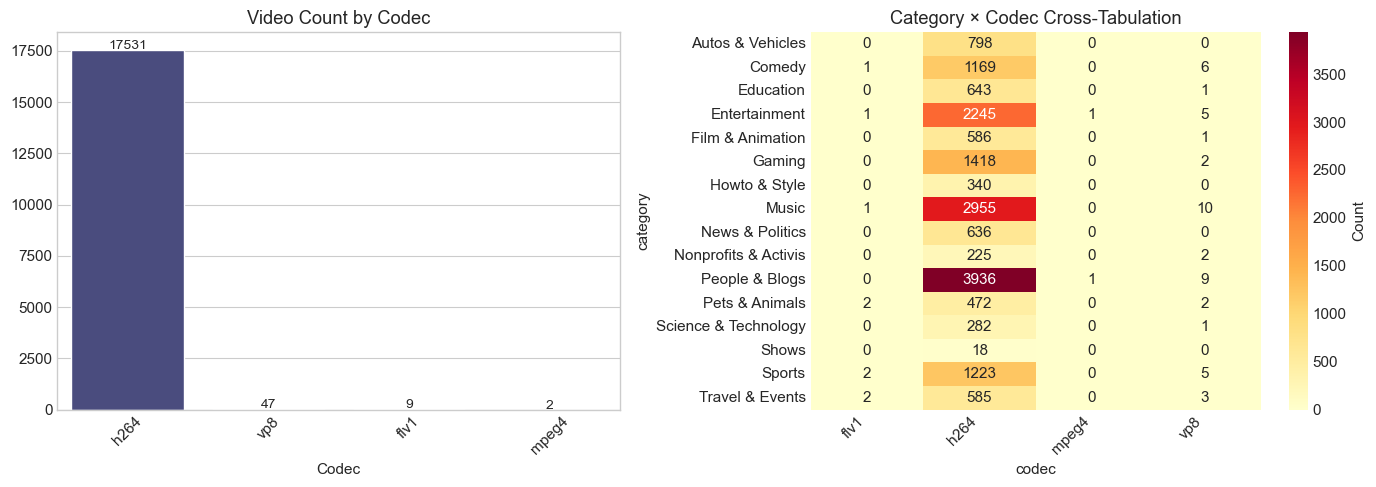

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Codec distribution
codec_counts = df['codec'].value_counts()
sns.barplot(x=codec_counts.index, y=codec_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Video Count by Codec')
axes[0].set_xlabel('Codec')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(codec_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=10)

# Category × Codec cross-tab (heatmap)
cross = pd.crosstab(df['category'], df['codec'])
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Category × Codec Cross-Tabulation')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 5. Numeric Distributions - Multi-View

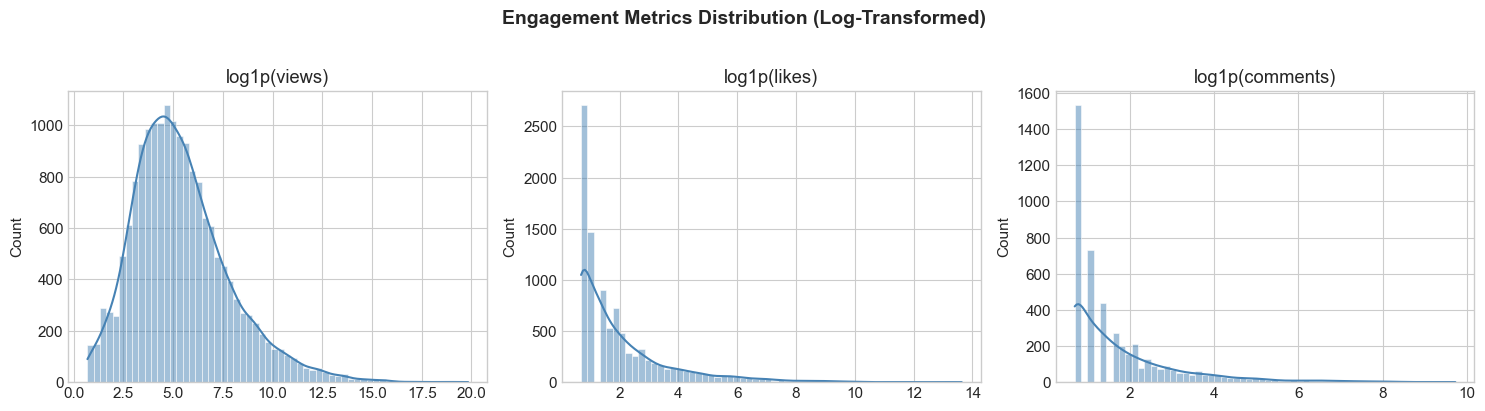

In [100]:
# Engagement metrics: histogram + KDE
eng_cols = ['views', 'likes', 'comments']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, eng_cols):
    data = np.log1p(df[col].replace(0, np.nan).dropna())
    sns.histplot(data, kde=True, ax=ax, bins=60, color='steelblue', edgecolor='white')
    ax.set_title(f'log1p({col})')
    ax.set_xlabel('')

plt.suptitle('Engagement Metrics Distribution (Log-Transformed)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

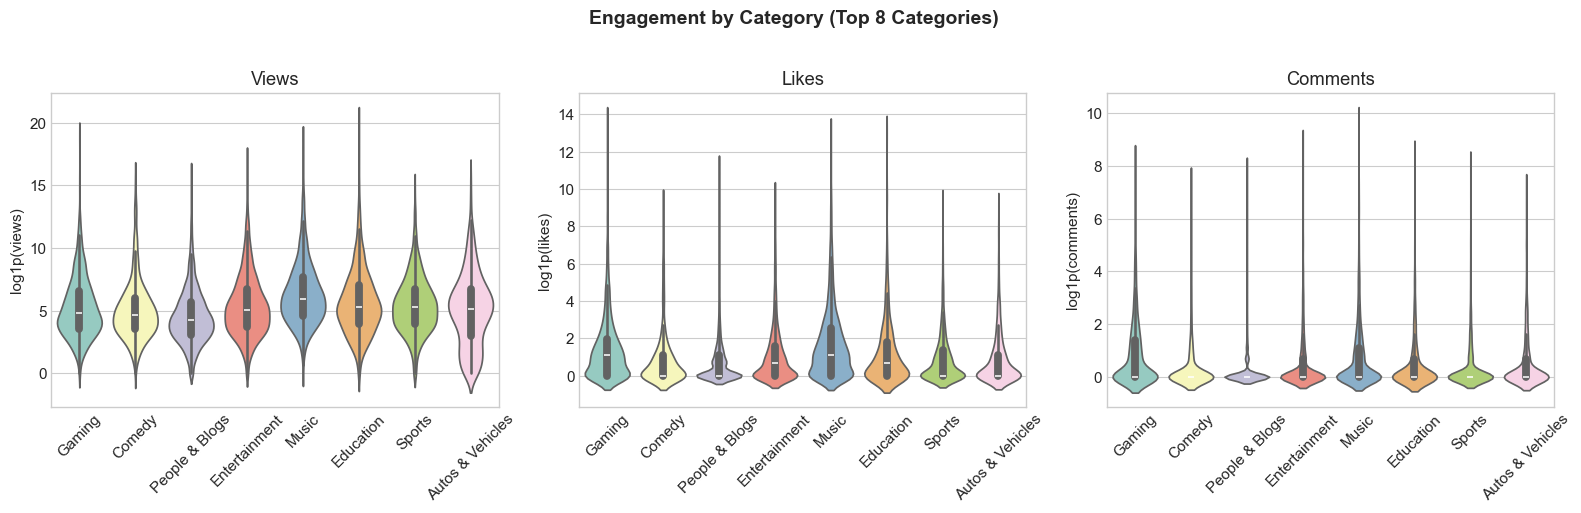

In [101]:
# Violin + Box plots for engagement by category (top categories)
top_categories = df['category'].value_counts().head(8).index.tolist()
df_top = df[df['category'].isin(top_categories)].copy()
df_top['log_views'] = np.log1p(df_top['views'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, log_col in zip(axes, ['views', 'likes', 'comments'], ['log_views', None, None]):
    if log_col and col == 'views':
        sns.violinplot(data=df_top, x='category', y='log_views', ax=ax, palette='Set3')
        ax.set_ylabel('log1p(views)')
    else:
        y_vals = np.log1p(df_top[col])
        plot_df = df_top.assign(log_val=y_vals)
        sns.violinplot(data=plot_df, x='category', y='log_val', ax=ax, palette='Set3')
        ax.set_ylabel(f'log1p({col})')
    ax.set_title(col.title())
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')

plt.suptitle('Engagement by Category (Top 8 Categories)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Analysis.** The distributions of engagement metrics and technical attributes reveal critical structural properties. Log-transformed views, likes, and comments exhibit right-skewed but more symmetric shapes, consistent with power-law or log-normal behaviour common in social media data. Violin plots by category demonstrate heterogeneous engagement across content types; this heterogeneity justifies category-informed modelling or stratification. The resolution scatter and duration–bitrate distributions indicate a mix of professional and user-generated content, with technical quality varying substantially. These findings support the use of distributional assumptions appropriate for heavy-tailed outcomes.

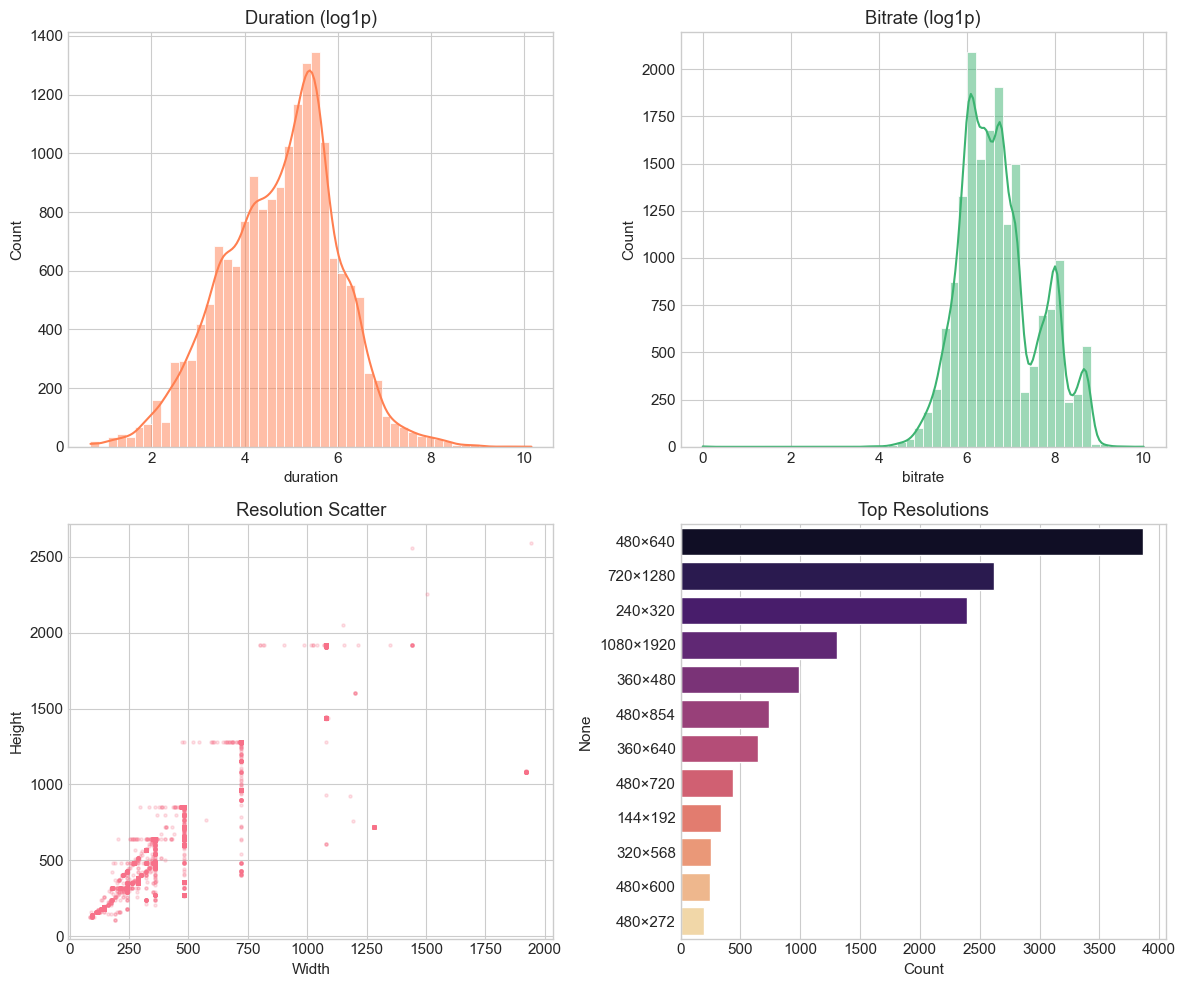

In [102]:
# Video technical attributes: duration, bitrate, resolution
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(np.log1p(df['duration']), kde=True, ax=axes[0,0], bins=50, color='coral')
axes[0,0].set_title('Duration (log1p)')

sns.histplot(np.log1p(df['bitrate']), kde=True, ax=axes[0,1], bins=50, color='mediumseagreen')
axes[0,1].set_title('Bitrate (log1p)')

axes[1,0].scatter(df['width'], df['height'], alpha=0.2, s=5)
axes[1,0].set_xlabel('Width')
axes[1,0].set_ylabel('Height')
axes[1,0].set_title('Resolution Scatter')

res_label = df['width'].astype(str) + '×' + df['height'].astype(str)
res_counts = res_label.value_counts().head(12)
sns.barplot(y=res_counts.index, x=res_counts.values, ax=axes[1,1], palette='magma')
axes[1,1].set_title('Top Resolutions')
axes[1,1].set_xlabel('Count')

plt.tight_layout()
plt.show()

---
## 6. Derived Features & Engagement Metrics

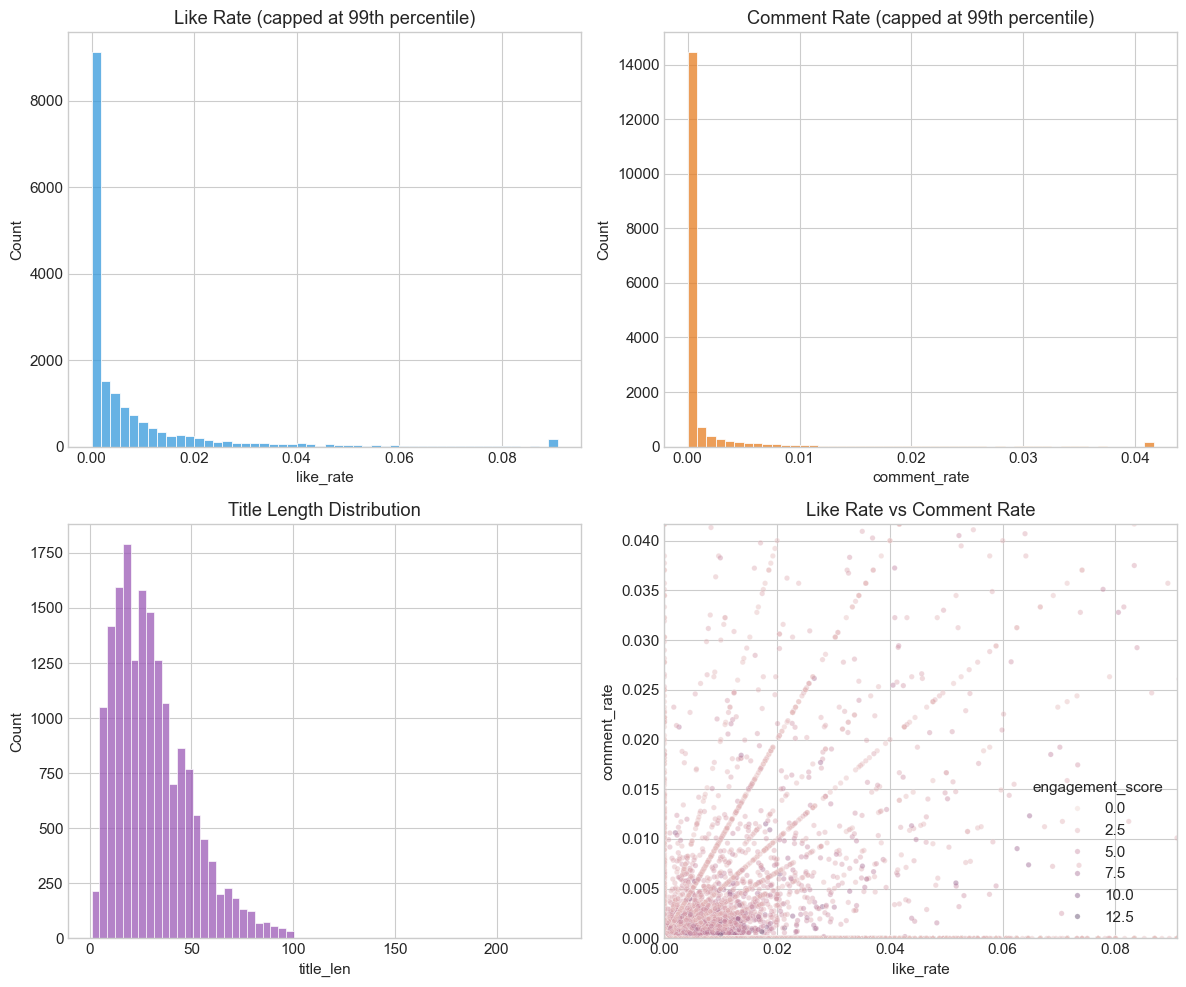

In [103]:
# Create derived features
df_eng = df.copy()
df_eng['like_rate'] = df_eng['likes'] / (df_eng['views'] + 1)
df_eng['comment_rate'] = df_eng['comments'] / (df_eng['views'] + 1)
df_eng['engagement_score'] = np.log1p(df_eng['likes'] + df_eng['comments'] * 2)  # weighted
df_eng['title_len'] = df_eng['title'].fillna('').str.len()
df_eng['hashtag_count'] = df_eng['hashtags'].fillna('').apply(lambda x: len([h for h in str(x).split(',') if h.strip()]) if pd.notna(x) and str(x).strip() else 0)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df_eng['like_rate'].clip(upper=df_eng['like_rate'].quantile(0.99)), ax=axes[0,0], bins=50, color='#3498db')
axes[0,0].set_title('Like Rate (capped at 99th percentile)')

sns.histplot(df_eng['comment_rate'].clip(upper=df_eng['comment_rate'].quantile(0.99)), ax=axes[0,1], bins=50, color='#e67e22')
axes[0,1].set_title('Comment Rate (capped at 99th percentile)')

sns.histplot(df_eng['title_len'], ax=axes[1,0], bins=60, color='#9b59b6')
axes[1,0].set_title('Title Length Distribution')

sns.scatterplot(data=df_eng, x='like_rate', y='comment_rate', hue='engagement_score', alpha=0.4, ax=axes[1,1], s=15)
axes[1,1].set_xlim(0, df_eng['like_rate'].quantile(0.99))
axes[1,1].set_ylim(0, df_eng['comment_rate'].quantile(0.99))
axes[1,1].set_title('Like Rate vs Comment Rate')

plt.tight_layout()
plt.show()

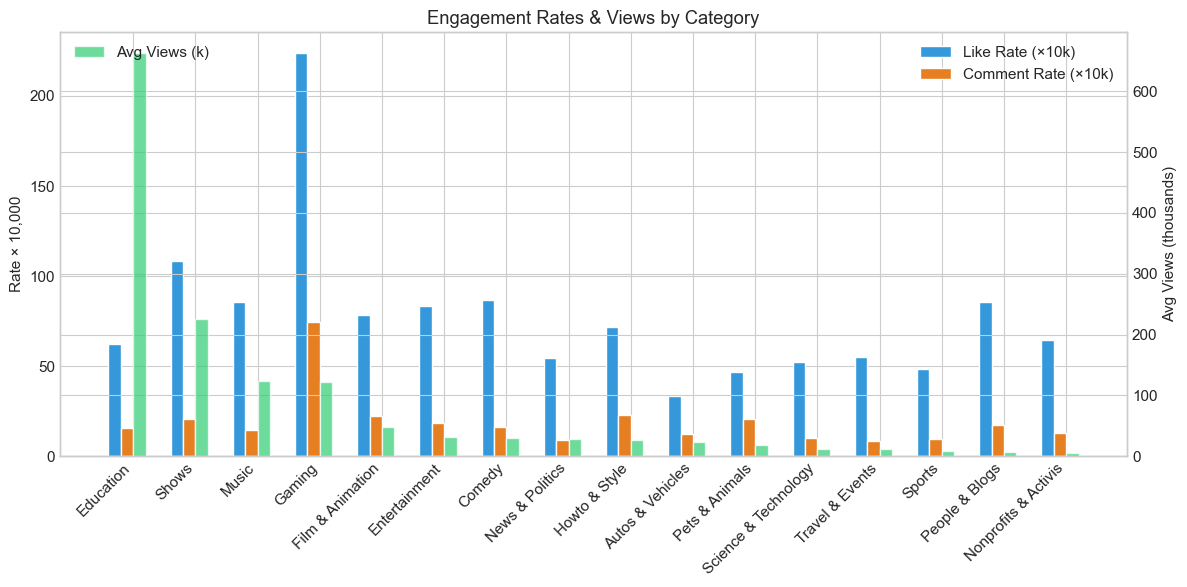

In [104]:
# Mean engagement rates by category
rate_by_cat = df_eng.groupby('category').agg({
    'like_rate': 'mean',
    'comment_rate': 'mean',
    'views': 'mean',
    'engagement_score': 'mean'
}).round(6)
rate_by_cat.columns = ['Avg Like Rate', 'Avg Comment Rate', 'Avg Views', 'Avg Engagement']
rate_by_cat = rate_by_cat.sort_values('Avg Views', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(rate_by_cat))
w = 0.2
ax.bar(x - 1.5*w, rate_by_cat['Avg Like Rate']*10000, width=w, label='Like Rate (×10k)', color='#3498db')
ax.bar(x - 0.5*w, rate_by_cat['Avg Comment Rate']*10000, width=w, label='Comment Rate (×10k)', color='#e67e22')
ax2 = ax.twinx()
ax2.bar(x + 0.5*w, rate_by_cat['Avg Views']/1000, width=w, label='Avg Views (k)', color='#2ecc71', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(rate_by_cat.index, rotation=45, ha='right')
ax.set_ylabel('Rate × 10,000')
ax2.set_ylabel('Avg Views (thousands)')
ax.legend(loc='upper right')
ax2.legend(loc='upper left')
ax.set_title('Engagement Rates & Views by Category')
plt.tight_layout()
plt.show()

**Analysis.** The derived engagement metrics—like rate, comment rate, and the composite engagement score—offer more nuanced measures than raw counts. The distributions of these rates, when capped at the 99th percentile, reveal typical viewer behaviour; the concentration of low rates suggests that high engagement is the exception rather than the norm. Cross-category comparison demonstrates that content type substantially influences both raw view counts and engagement intensity. Categories with high mean views may exhibit lower like or comment rates, indicating that reach and depth of engagement are distinct dimensions. These metrics are well-suited as targets for predictive modelling or as features in content recommendation systems.

---
## 7. Correlation & Relationship Analysis

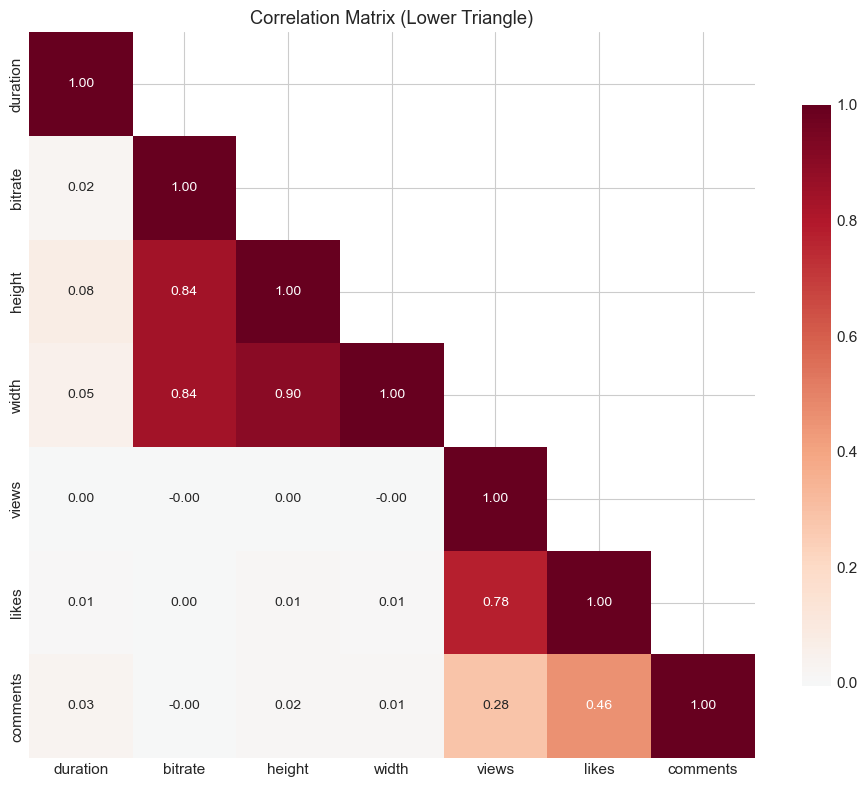

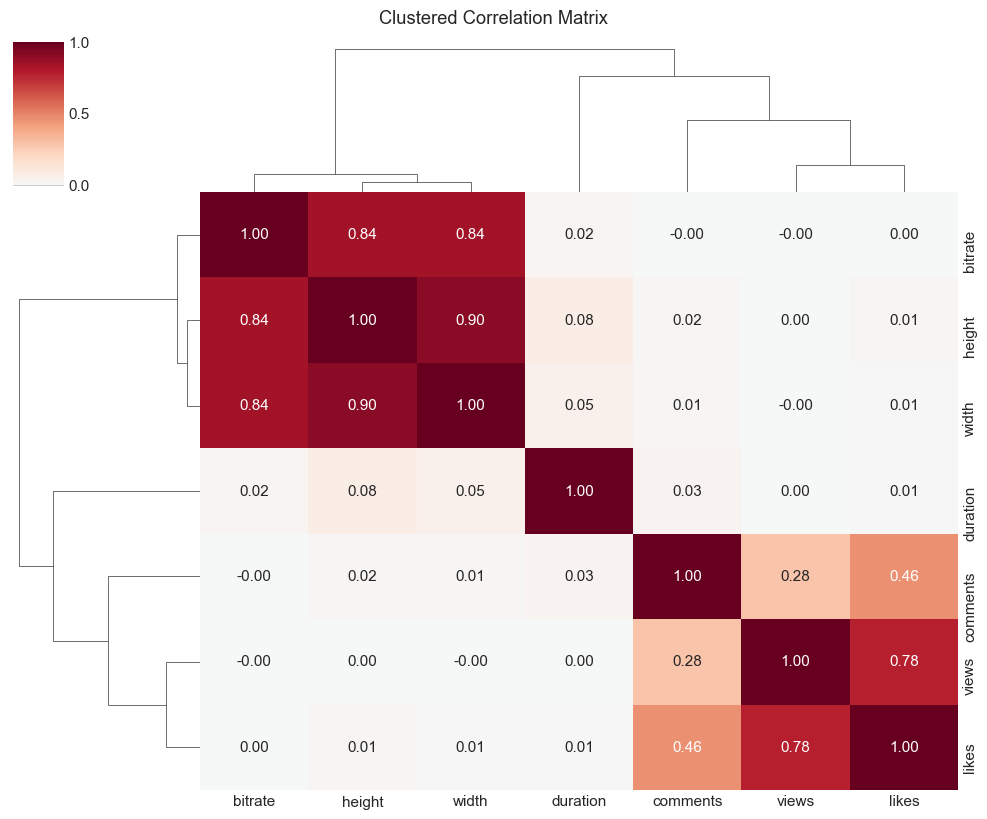

In [105]:
corr_cols = ['duration', 'bitrate', 'height', 'width', 'views', 'likes', 'comments']
corr_cols = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].corr()

# Correlation heatmap (lower triangle)
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True, 
            ax=ax, cbar_kws={'shrink': 0.8}, annot_kws={'size': 10})
ax.set_title('Correlation Matrix (Lower Triangle)')
plt.tight_layout()
plt.show()

# Clustered correlation (creates its own figure)
g = sns.clustermap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', figsize=(10, 8))
g.fig.suptitle('Clustered Correlation Matrix', y=1.02)
plt.show()

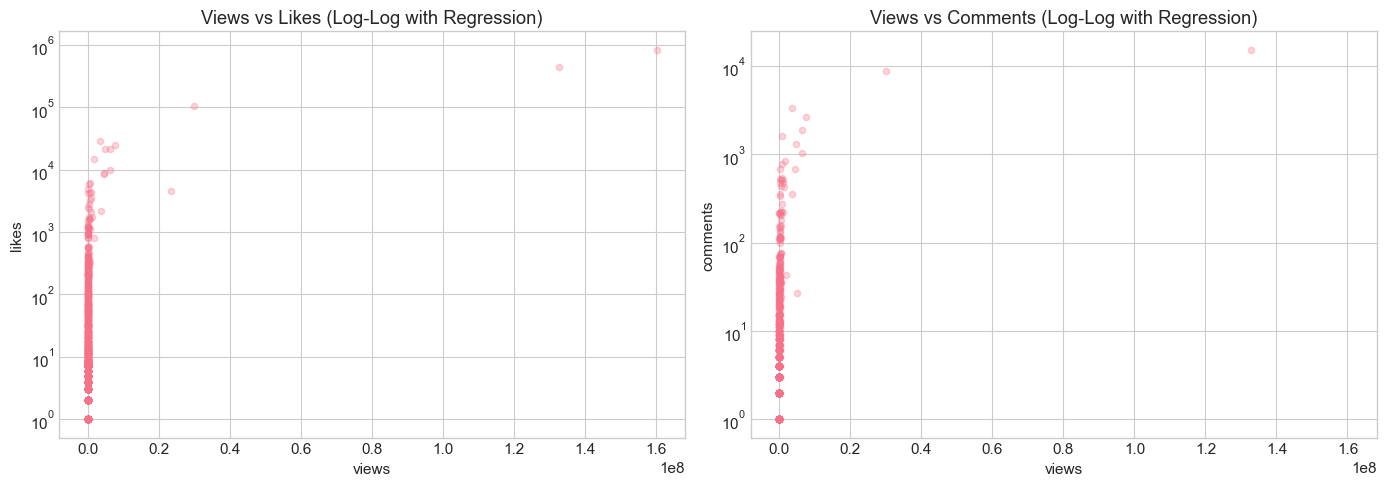

In [106]:
# Pairwise scatter with regression (Views vs Likes, Views vs Comments)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df.sample(min(3000, len(df)), random_state=42)

sns.regplot(data=sample, x='views', y='likes', ax=axes[0], scatter_kws={'alpha': 0.3, 's': 20}, 
            line_kws={'color': 'red', 'lw': 2}, logx=True)
axes[0].set_yscale('log')
axes[0].set_title('Views vs Likes (Log-Log with Regression)')

sns.regplot(data=sample, x='views', y='comments', ax=axes[1], scatter_kws={'alpha': 0.3, 's': 20}, 
            line_kws={'color': 'red', 'lw': 2}, logx=True)
axes[1].set_yscale('log')
axes[1].set_title('Views vs Comments (Log-Log with Regression)')

plt.tight_layout()
plt.show()

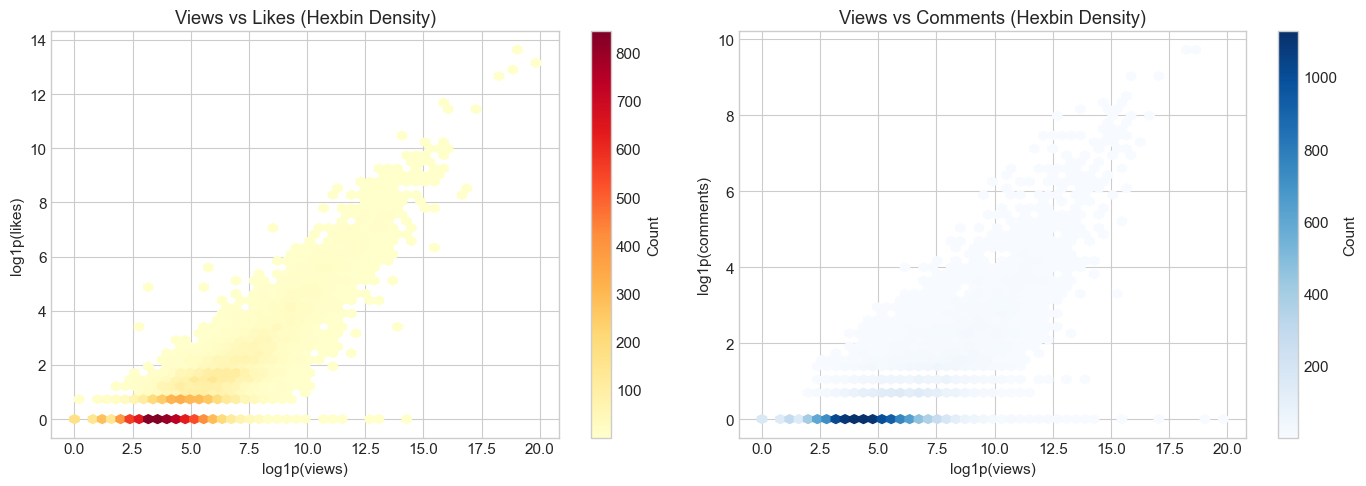

In [107]:
# Hexbin for density (views vs likes)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

h1 = axes[0].hexbin(np.log1p(df['views']), np.log1p(df['likes']), gridsize=50, cmap='YlOrRd', mincnt=1)
plt.colorbar(h1, ax=axes[0], label='Count')
axes[0].set_xlabel('log1p(views)')
axes[0].set_ylabel('log1p(likes)')
axes[0].set_title('Views vs Likes (Hexbin Density)')

h2 = axes[1].hexbin(np.log1p(df['views']), np.log1p(df['comments']), gridsize=50, cmap='Blues', mincnt=1)
plt.colorbar(h2, ax=axes[1], label='Count')
axes[1].set_xlabel('log1p(views)')
axes[1].set_ylabel('log1p(comments)')
axes[1].set_title('Views vs Comments (Hexbin Density)')

plt.tight_layout()
plt.show()

**Analysis.** The correlation structure among numeric variables carries implications for model specification and multicollinearity. Strong positive correlations between views, likes, and comments align with the premise that engagement metrics share common drivers; redundant inclusion of highly correlated predictors may inflate variance and obscure interpretation. The associations between technical attributes (duration, bitrate, resolution) and engagement are of particular interest for understanding whether production quality influences audience retention. The clustered correlation matrix aids in identifying variable groups that may be collapsed or regularised. These findings inform feature selection and the choice of regularisation in predictive modelling.

---
## 8. Outlier Detection & Robustness

In [108]:
# IQR-based outlier counts
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return ((series < low) | (series > high)).sum()

outlier_counts = pd.DataFrame({
    'Column': ['views', 'likes', 'comments', 'duration'],
    'Outliers (IQR)': [count_outliers_iqr(df[c]) for c in ['views', 'likes', 'comments', 'duration']],
    'Pct (%)': [(count_outliers_iqr(df[c])/len(df)*100).round(2) for c in ['views', 'likes', 'comments', 'duration']]
})
outlier_counts

,Column,Outliers (IQR),Pct (%)
0,views,2888,16.42
1,likes,2565,14.58
2,comments,2424,13.78
3,duration,1376,7.82


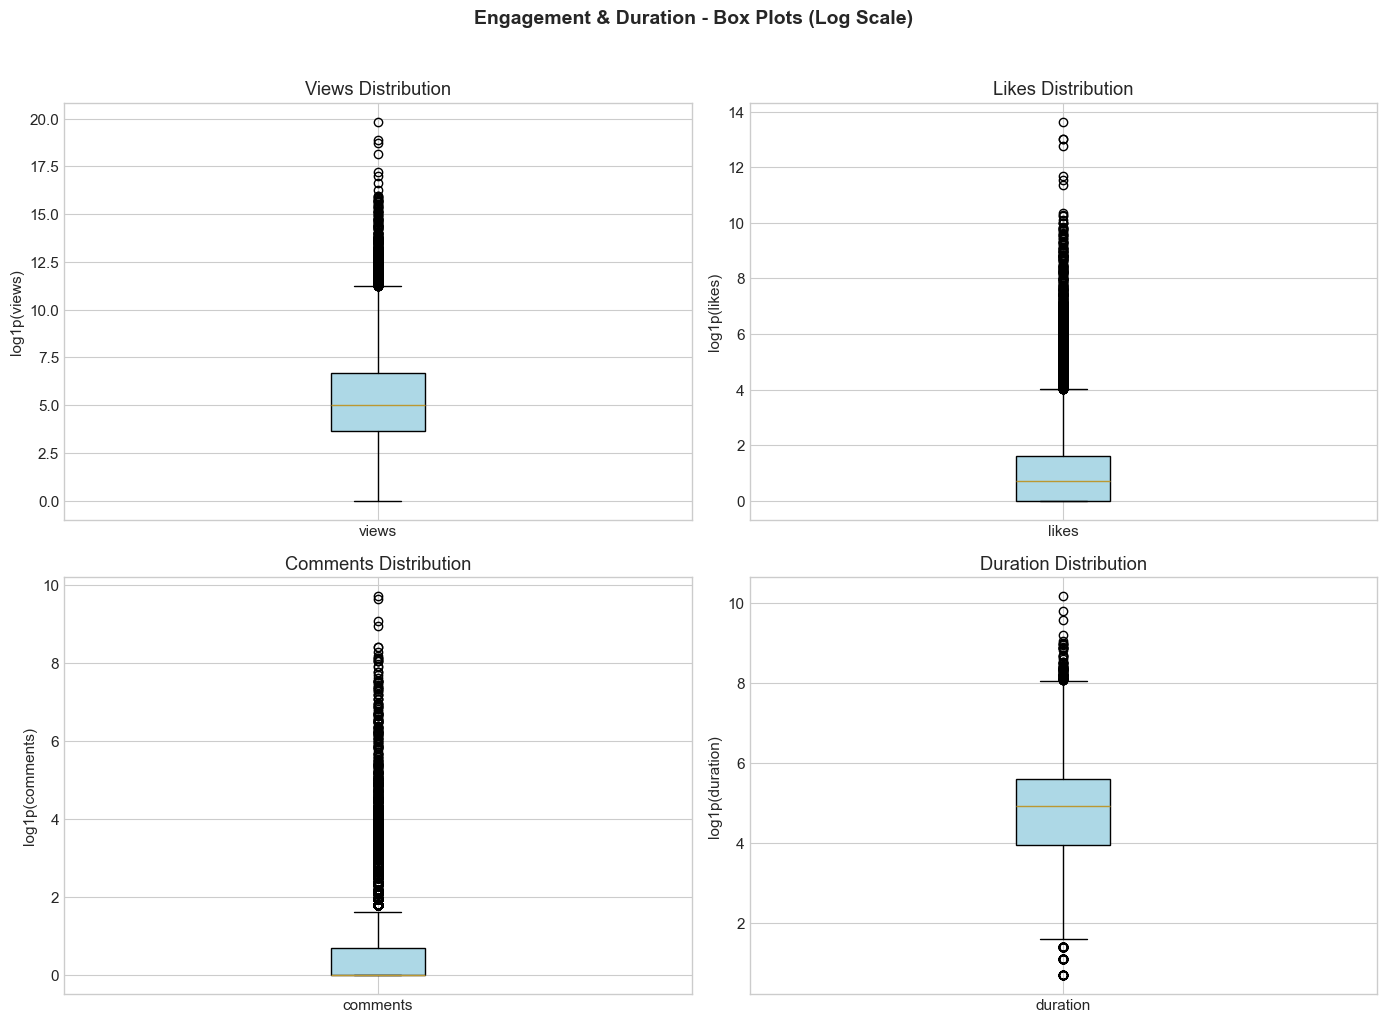

In [109]:
# Box plots with swarm overlay (sample)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, ['views', 'likes', 'comments', 'duration']):
    data = np.log1p(df[col])
    bp = ax.boxplot([data], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    ax.set_ylabel(f'log1p({col})')
    ax.set_title(f'{col.title()} Distribution')
    ax.set_xticklabels([col])

plt.suptitle('Engagement & Duration - Box Plots (Log Scale)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

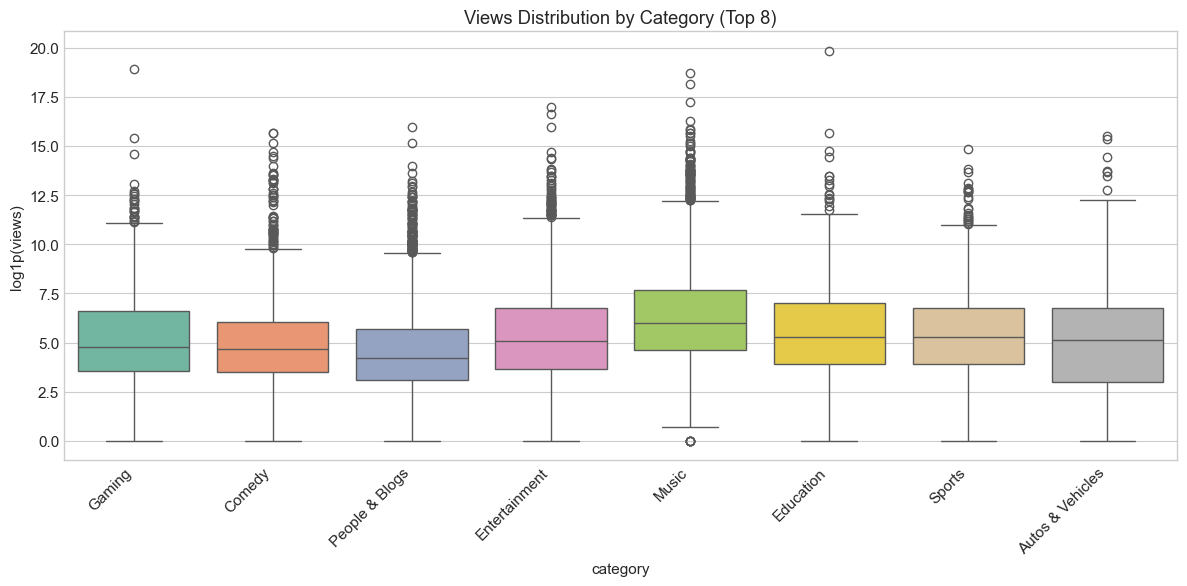

In [110]:
# Box plot by category for views (top categories)
top_categories = df['category'].value_counts().head(8).index.tolist()
df_top = df[df['category'].isin(top_categories)].copy()
df_top['log_views'] = np.log1p(df_top['views'])

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x='category', y='log_views', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.ylabel('log1p(views)')
plt.title('Views Distribution by Category (Top 8)')
plt.tight_layout()
plt.show()

**Analysis.** Outlier detection via the interquartile range reveals the extent of extreme values in engagement and duration. The heavy right-tailed nature of views, likes, and comments ensures that a substantial proportion of observations fall beyond conventional 1.5×IQR bounds; such behaviour is characteristic of social media metrics. Box plots by category illustrate that outlier prevalence varies across content types, with some categories exhibiting more variable engagement. These findings justify robust estimation methods, log or rank transformations, or separate modelling of the tail. Outlier treatment should be documented and justified, as exclusion may bias inference toward typical rather than viral content.

---
## 9. Video Quality & Resolution Analysis

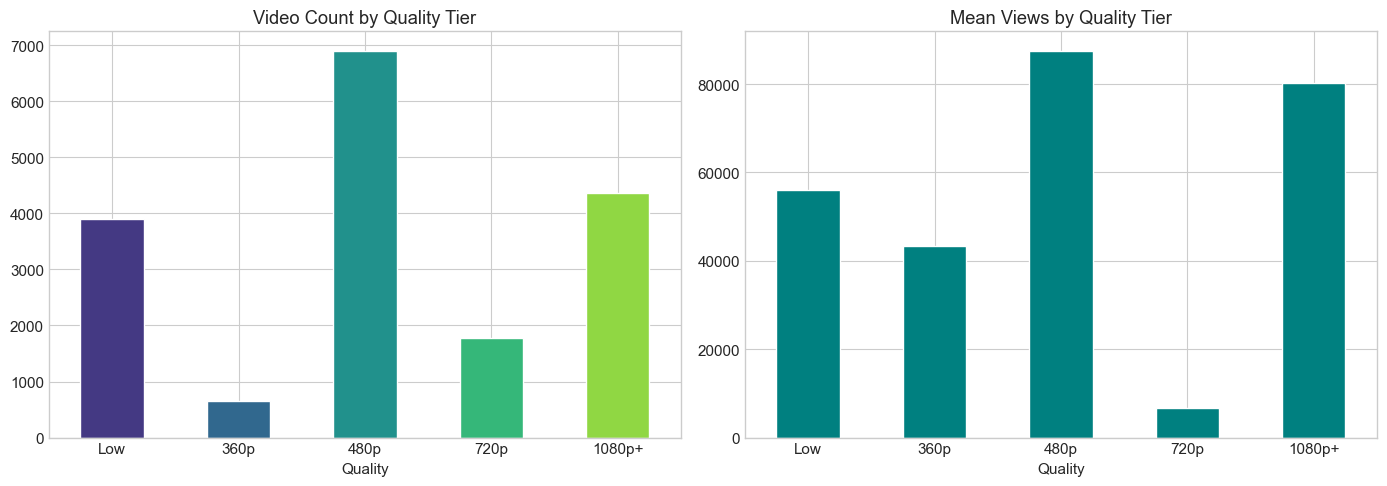

In [111]:
# Aspect ratio and quality tier
df_res = df.copy()
df_res['aspect_ratio'] = df_res['width'] / (df_res['height'] + 1e-6)
df_res['pixels'] = df_res['width'] * df_res['height']

def quality_tier(row):
    w, h = row['width'], row['height']
    if w >= 1920 or h >= 1080: return '1080p+'  
    if w >= 1280 or h >= 720: return '720p'
    if w >= 854 or h >= 480: return '480p'
    if w >= 640 or h >= 360: return '360p'
    return 'Low'

df_res['quality_tier'] = df_res.apply(quality_tier, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

quality_order = ['Low', '360p', '480p', '720p', '1080p+']
qt_counts = df_res['quality_tier'].value_counts().reindex(quality_order).dropna()
if len(qt_counts) > 0:
    qt_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('viridis', len(qt_counts)))
axes[0].set_title('Video Count by Quality Tier')
axes[0].set_xlabel('Quality')
axes[0].tick_params(axis='x', rotation=0)

mean_views_qt = df_res.groupby('quality_tier')['views'].mean().reindex(quality_order).dropna()
if len(mean_views_qt) > 0:
    mean_views_qt.plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Mean Views by Quality Tier')
axes[1].set_xlabel('Quality')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Analysis.** The relationship between video quality tier and both video count and mean views informs hypotheses about production investment and audience response. The distribution of videos across quality tiers reflects the mix of professional and amateur content on the platform. If higher-quality tiers are associated with greater mean views, this suggests that production value may confer an advantage in discoverability or retention; conversely, a weak or inverse relationship would imply that content factors dominate technical quality. These patterns have implications for platform design and for feature engineering in engagement prediction models.

---
## 10. Text Features (Title & Hashtags)

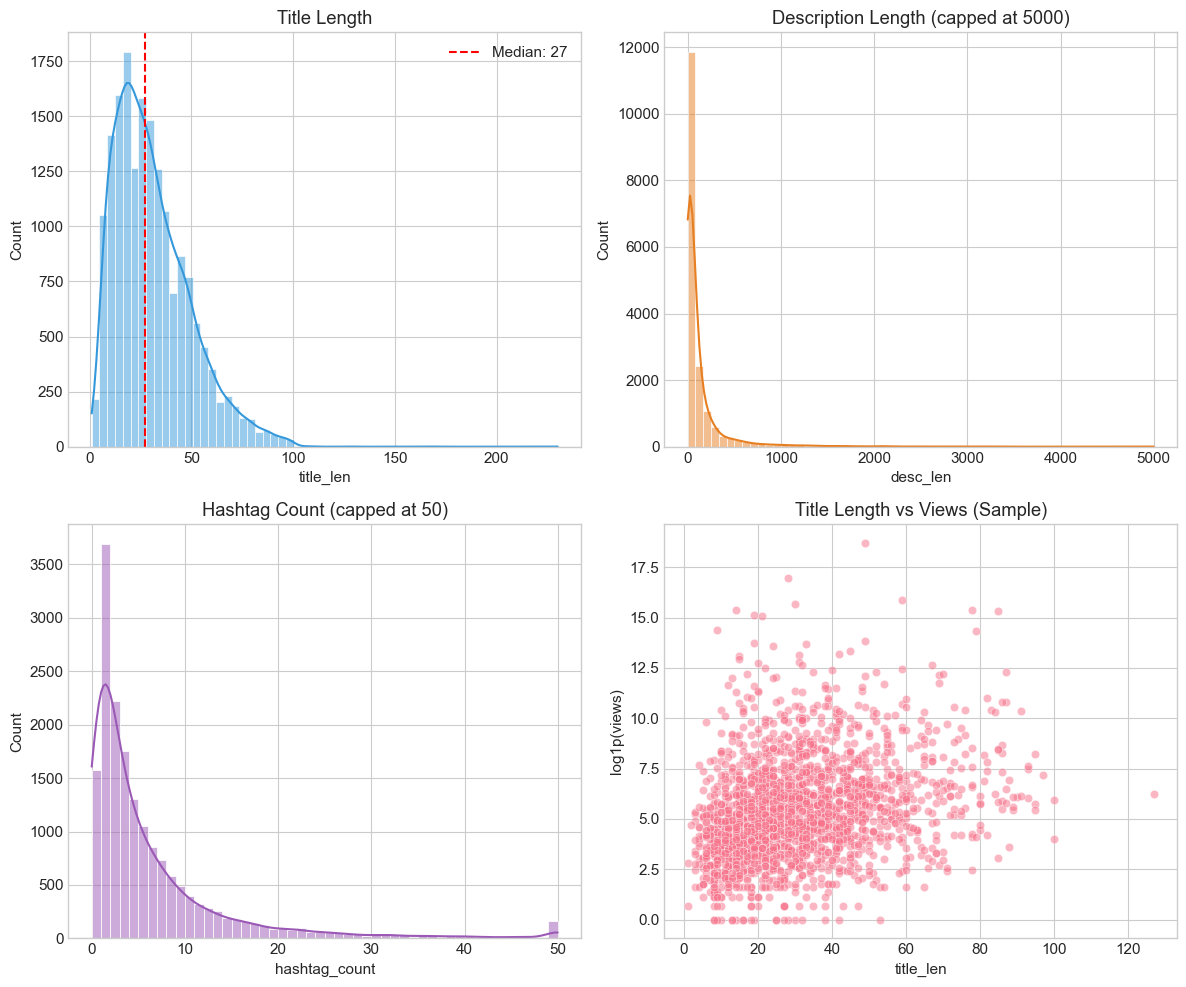

In [112]:
df_txt = df.copy()
df_txt['title_len'] = df_txt['title'].fillna('').str.len()
df_txt['desc_len'] = df_txt['description'].fillna('').str.len()
df_txt['hashtag_count'] = df_txt['hashtags'].fillna('').apply(lambda x: len([h for h in str(x).split(',') if h.strip()]) if pd.notna(x) and str(x).strip() else 0)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(df_txt['title_len'], ax=axes[0,0], bins=60, kde=True, color='#3498db')
axes[0,0].axvline(df_txt['title_len'].median(), color='red', linestyle='--', label=f"Median: {df_txt['title_len'].median():.0f}")
axes[0,0].set_title('Title Length')
axes[0,0].legend()

sns.histplot(df_txt['desc_len'].clip(upper=5000), ax=axes[0,1], bins=60, kde=True, color='#e67e22')
axes[0,1].set_title('Description Length (capped at 5000)')

sns.histplot(df_txt['hashtag_count'].clip(upper=50), ax=axes[1,0], bins=50, kde=True, color='#9b59b6')
axes[1,0].set_title('Hashtag Count (capped at 50)')

sample_txt = df_txt.sample(min(2000, len(df_txt)), random_state=42)
sns.scatterplot(data=sample_txt, x='title_len', y=np.log1p(sample_txt['views']), alpha=0.5, ax=axes[1,1])
axes[1,1].set_ylabel('log1p(views)')
axes[1,1].set_title('Title Length vs Views (Sample)')

plt.tight_layout()
plt.show()

**Analysis.** Title length, description length, and hashtag count serve as proxies for creator effort and metadata completeness. The distributions of these text-derived features indicate typical content presentation strategies. The scatter of title length against views explores whether concision or elaboration is associated with higher engagement; a weak or absent relationship would suggest that other factors—such as category, thumbnail, or recommendation placement—dominate. These findings inform the inclusion of text features in predictive models and the design of creator guidelines for metadata optimisation.

---
## 11. Key Findings Summary

**Summary and Implications.** The exploratory analysis yields several substantive conclusions. First, engagement metrics exhibit pronounced right skew and power-law-like distributions, necessitating appropriate transformations and distributional assumptions in modelling. Second, categorical content type is a strong determinant of both raw engagement and engagement rates; category-informed specifications are warranted. Third, technical attributes (resolution, bitrate) and encoding (codec) show limited discriminatory power relative to semantic and engagement features. Fourth, correlation among views, likes, and comments supports dimensionality reduction or careful regularisation when multiple engagement outcomes are modelled. Fifth, the presence of missing data and potential duplicates requires documented preprocessing before inference. These findings establish the analytical foundation for model development and validation.

In [113]:
print('='*60)
print('EDA SUMMARY - YouTube Video Dataset')
print('='*60)
print(f'\n📊 Dataset: {len(df):,} videos, {len(df.columns)} columns')
print(f'\n📌 Categories: {df["category"].nunique()} unique')
print(f'   Top 3: {list(df["category"].value_counts().head(3).index)}')
print(f'\n📌 Views: min={df["views"].min():,.0f}, max={df["views"].max():,.0f}, median={df["views"].median():,.0f}')
print(f'\n📌 Correlations:')
print(f'   views-likes: {df["views"].corr(df["likes"]):.3f}')
print(f'   views-comments: {df["views"].corr(df["comments"]):.3f}')
print(f'   likes-comments: {df["likes"].corr(df["comments"]):.3f}')
print(f'\n📌 Missing: {df.isnull().sum().sum()} total missing values across {df.isnull().any(axis=0).sum()} columns')
print(f'\n📌 Duplicates: {df["video_id"].duplicated().sum()} duplicate video_ids')
print('='*60)

EDA SUMMARY - YouTube Video Dataset

📊 Dataset: 17,589 videos, 17 columns

📌 Categories: 16 unique
   Top 3: ['People & Blogs', 'Music', 'Entertainment']

📌 Views: min=0, max=410,384,910, median=152

📌 Correlations:
   views-likes: 0.778
   views-comments: 0.284
   likes-comments: 0.461

📌 Missing: 2688 total missing values across 2 columns

📌 Duplicates: 0 duplicate video_ids
